# 06 — Transaction screening: catching sales that are not market sales

This notebook asks whether a non-market sale (a foreclosure, a transfer between relatives, a part-built new home) can be flagged from the transaction's own attributes, without waiting for the assessor's `Sale Condition` field. Notebook 03 used that field to remove them, but in a live feed it is often late, blank or wrong. Notebook 05 showed what happens when these sales get into training: valuations on that population are 49% worse and five of six monitoring controls trip. Using the Ames sales, split by time as elsewhere, two screens are built: one that runs before a price exists and one that also uses the gap between the agreed price and the AVM's valuation. Only 17.6% of sales are non-market, so a model that always answers "market sale" is right 82.4% of the time and accuracy is not a useful measure; the notebook uses precision, recall, PR-AUC and lift instead (a lift of 4 means reviewing 10% of sales finds 40% of the non-market ones). Knowing the agreed price roughly doubles what the screen can do (§4), which is why two separate screens exist (§5 onward).

Terms are defined in [the glossary](../docs/GLOSSARY.md).

In [1]:
import json
import os

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.pipeline import Pipeline

from ames.compat import silence_spurious_matmul_warnings, worker_warning_filter
from ames.config import ARMS_LENGTH_CONDITION, PROCESSED, SEED
from ames.data import load_properties
from ames.features import build_preprocessor, prepare, split_feature_types
from ames.screening import (best_threshold, calibration_table, cost_optimal_threshold,
                            discrimination_scorecard, gains_table, ks_statistic,
                            threshold_sweep)
from ames.viz import (AQUA, BLUE, CATEGORICAL_3, CONTEXT, CONTEXT_DARK, CONTRAST,
                      CONTRAST_FILL, DIVERGING, GRID, INK_MUTED, INK_SECONDARY,
                      ORANGE, PANEL, SEQUENTIAL, STATUS, SUBJECT, SUBJECT_FILL,
                      SURFACE, VIOLET, annotate, axis_note, band, bar_labels,
                      callout, dumbbell, emphasise, era, fig_titled, hero,
                      label_end, legend_above, money, pct, pct1, reference_line,
                      save, titled, use_style)

use_style()

silence_spurious_matmul_warnings()
os.environ["PYTHONWARNINGS"] = worker_warning_filter()
pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 40)

# The figure furniture every chart in this notebook shares: which notebook you are in,
# and where the numbers came from.  Defined once so the nine notebooks read as one report.
KICKER = "06 · Transaction screening"
SOURCE = "Source: De Cock (2011) · 989 held-out transactions, 12.8% non-market."

def finish(fig, headline, standfirst=None, source=SOURCE):
    """Add the editorial title block and source note."""
    fig_titled(fig, headline, standfirst, kicker=KICKER, source=source)

data = prepare(load_properties())
data["non_market"] = (data["Sale Condition"] != ARMS_LENGTH_CONDITION).astype(int)

print(f"{len(data):,} sales · {data['non_market'].sum():,} non-market "
      f"({data['non_market'].mean():.1%})")

2,930 sales · 517 non-market (17.6%)


## 1. What the screen is trying to catch

The positive class pools five different situations, and they distort price in **opposite directions**. That is why the AVM cannot simply learn to handle them.

In [2]:
breakdown = (data.groupby("Sale Condition")
             .agg(n=("SalePrice", "size"),
                  median_price=("SalePrice", "median"),
                  median_sqft=("Gr Liv Area", "median"),
                  median_age=("house_age", "median"),
                  median_qual=("Overall Qual", "median")))
breakdown["price_per_sqft"] = (data.groupby("Sale Condition")
                               .apply(lambda g: (g["SalePrice"] / g["Gr Liv Area"]).median(),
                                      include_groups=False))
normal_psf = breakdown.loc[ARMS_LENGTH_CONDITION, "price_per_sqft"]
breakdown["distortion"] = breakdown["price_per_sqft"] / normal_psf - 1
breakdown["share"] = breakdown["n"] / len(data)
breakdown.sort_values("n", ascending=False).round(3)

,n,median_price,median_sqft,median_age,median_qual,price_per_sqft,distortion,share
Sale Condition,,,,,,,,
Normal,2413,159000.0,1431.0,37.0,6.0,119.306,0.000,0.824
Partial,245,250000.0,1652.0,1.0,8.0,149.829,0.256,0.084
Abnorml,190,129450.0,1282.5,48.0,5.0,100.876,-0.154,0.065
Family,46,144400.0,1372.0,45.0,6.0,111.127,-0.069,0.016
Alloca,24,149617.0,1428.5,34.5,5.0,85.210,-0.286,0.008
AdjLand,12,110000.0,1162.5,74.5,5.0,83.757,-0.298,0.004


`Partial` sales price **26% above** market per square foot (new builds assessed before completion); `AdjLand` and `Alloca` price around **30% below**. Averaged together the effects cancel, so these sales have to be excluded rather than modelled.

## 2. The design decision: what is known, and when?

An obvious feature is the distance between the sale price and the AVM's estimate: a foreclosure selling 15% under the model's value is a strong signal. But that feature only exists once a price has been agreed, and the two uses of a screen happen at different moments:

| | When it runs | Can it use the price? | What it is for |
|---|---|---|---|
| **Pre-transaction screen** | Before or without a sale | **No** | Scoring a property in a portfolio; flagging listings |
| **Post-transaction screen** | After the sale closes | **Yes** | Gating what enters the AVM's training data |

Both are built below and compared. Building only the second and quoting its accuracy for both uses would be a leakage error.

In [3]:
LEAKY = {"SalePrice", "Sale Condition", "non_market", "avm_residual", "avm_value"}
numeric, nominal = split_feature_types(data)
numeric = [c for c in numeric if c not in LEAKY]
nominal = [c for c in nominal if c not in LEAKY]
print(f"pre-transaction features: {len(numeric)} numeric + {len(nominal)} nominal")

pre-transaction features: 81 numeric + 20 nominal


### Using one model's output as another model's input

The post-transaction feature is the gap between the agreed price and the AVM's own valuation. Fed naively into a second model, it leaks: for any row the AVM was trained on, the residual is near zero because the model has already fitted that house.

If the screen's training rows carry near-zero residuals and its test rows carry real out-of-sample ones, the feature means different things in the two halves, and the relationship the screen learns disappears in production.

The fix is **cross-fitting**. The data is split into folds, and each fold's AVM valuation comes from a model fitted only on the other folds, so every row gets a residual the AVM could not have memorised.

In [4]:
import joblib
from sklearn.base import clone
from sklearn.model_selection import KFold

from ames.avm import duan_smearing_factor

avm = joblib.load(PROCESSED / "avm_model.joblib")

def fit_avm(rows: pd.DataFrame):
    """Fit the AVM on the arm's-length, non-outlier subset of ``rows``."""
    clean = rows[(rows["Sale Condition"] == ARMS_LENGTH_CONDITION)
                 & (~rows["is_outlier_grlivarea"])]
    y = np.log(clean["SalePrice"])
    model = clone(avm["estimator"]).fit(clean, y)
    return model, np.log(duan_smearing_factor(y - model.predict(clean)))

def cross_fitted_values(frame: pd.DataFrame, n_splits: int = 5) -> pd.Series:
    """Out-of-sample AVM valuation for every row in ``frame``."""
    values = pd.Series(np.nan, index=frame.index, dtype=float)
    for fit_pos, pred_pos in KFold(n_splits, shuffle=True, random_state=SEED).split(frame):
        model, sm = fit_avm(frame.iloc[fit_pos])
        values.iloc[pred_pos] = np.exp(model.predict(frame.iloc[pred_pos]) + sm)
    return values

# Naive version, for comparison only -- fit once on the training window, applied to all.
train_rows = data[data["temporal_split"] == "train"]
naive_model, naive_smear = fit_avm(train_rows)
naive_value = np.exp(naive_model.predict(data) + naive_smear)

# Cross-fitted within the training window; test rows use a model fitted on all of it.
data["avm_value"] = np.nan
data.loc[train_rows.index, "avm_value"] = cross_fitted_values(train_rows)
test_rows = data[data["temporal_split"] == "test"]
data.loc[test_rows.index, "avm_value"] = np.exp(naive_model.predict(test_rows) + naive_smear)
data["avm_residual"] = np.log(data["SalePrice"]) - np.log(data["avm_value"])

leak_check = pd.DataFrame({
    "naive (AVM saw these rows)": (np.log(data["SalePrice"]) - np.log(naive_value)).abs()
        .groupby(data["temporal_split"]).median(),
    "cross-fitted (never saw them)": data["avm_residual"].abs()
        .groupby(data["temporal_split"]).median(),
})
print("Median |price gap| the screen gets to see:\n")
print(leak_check.round(4).to_string())

Median |price gap| the screen gets to see:

                naive (AVM saw these rows)  cross-fitted (never saw them)
temporal_split                                                           
test                                0.0603                         0.0603
train                               0.0233                         0.0535


In the naive column, the gap on training rows is about 2.6 times smaller than on test rows, purely because the AVM had already fitted them. Cross-fitting removes the difference, and everything below uses the cross-fitted feature.

In [5]:
print(f"median price gap, market sales:     "
      f"{data.loc[data.non_market == 0, 'avm_residual'].median():+.3f}")
print(f"median price gap, non-market sales: "
      f"{data.loc[data.non_market == 1, 'avm_residual'].median():+.3f}")
print(f"spread (IQR), market:     "
      f"{data.loc[data.non_market == 0, 'avm_residual'].quantile([.25,.75]).diff().iloc[-1]:.3f}")
print(f"spread (IQR), non-market: "
      f"{data.loc[data.non_market == 1, 'avm_residual'].quantile([.25,.75]).diff().iloc[-1]:.3f}")

median price gap, market sales:     +0.004
median price gap, non-market sales: +0.001
spread (IQR), market:     0.102
spread (IQR), non-market: 0.165


## 3. Train / test split and class imbalance

The same temporal split as elsewhere: fit on 2006–2008, test on 2009–July 2010.

SMOTE, the usual advice for imbalanced problems, is not used. Synthesising minority examples inflates the apparent positive rate, so a predicted 0.5 no longer means "half of these are non-market", and §6 needs real probabilities for a cost-based decision.

`class_weight="balanced"` is used instead to make the models attend to the rare class. It has the same side effect for the same reason; §5 measures and corrects it.

The positive rate also shifts across the split: 20.1% of 2006–2008 sales are non-market against 12.8% in 2009–2010, because the new-construction boom that produced `Partial` sales ended. A moving base rate is another reason to recalibrate rather than trust raw scores.

In [6]:
train = data[data["temporal_split"] == "train"]
test = data[data["temporal_split"] == "test"]
y_train, y_test = train["non_market"], test["non_market"]

print(f"train {len(train):,} ({y_train.mean():.1%} non-market) · "
      f"test {len(test):,} ({y_test.mean():.1%} non-market)")

CV = GroupKFold(n_splits=5)

fitted: dict[str, Pipeline] = {}

def fit_screen(features_numeric, features_nominal, label: str):
    """Fit a regularised logistic scorecard and a gradient-boosted model."""
    out = {}
    specs = {
        "Logistic": (LogisticRegression(max_iter=5000, class_weight="balanced",
                                        random_state=SEED),
                     {"model__C": np.logspace(-3, 1, 9)}, True),
        "LightGBM": (lgb.LGBMClassifier(random_state=SEED, verbose=-1, n_jobs=1,
                                        class_weight="balanced", n_estimators=400),
                     {"model__learning_rate": [0.03, 0.08],
                      "model__num_leaves": [15, 31],
                      "model__min_child_samples": [15, 30]}, False),
    }
    for name, (estimator, grid, scale) in specs.items():
        pipe = Pipeline([("prep", build_preprocessor(features_numeric, features_nominal,
                                                     scale=scale)),
                         ("model", estimator)])
        search = GridSearchCV(pipe, grid, cv=CV, scoring="average_precision", n_jobs=-1)
        search.fit(train, y_train, groups=train["Neighborhood"])
        out[f"{label} · {name}"] = search.best_estimator_.predict_proba(test)[:, 1]
        fitted[f"{label} · {name}"] = search.best_estimator_
        print(f"  {label:18s} {name:9s} CV PR-AUC {search.best_score_:.4f}")
    return out

print("pre-transaction (property attributes only)")
scores = fit_screen(numeric, nominal, "Pre-transaction")
print("post-transaction (adds the AVM price gap)")
scores.update(fit_screen(numeric + ["avm_residual"], nominal, "Post-transaction"))
estimators = fitted

train 1,941 (20.1% non-market) · test 989 (12.8% non-market)
pre-transaction (property attributes only)


  Pre-transaction    Logistic  CV PR-AUC 0.4447


  Pre-transaction    LightGBM  CV PR-AUC 0.6323
post-transaction (adds the AVM price gap)


  Post-transaction   Logistic  CV PR-AUC 0.4423


  Post-transaction   LightGBM  CV PR-AUC 0.6729


## 4. How well does it work?

ROC-AUC is reported alongside PR-AUC because on an imbalanced problem ROC-AUC rewards ranking the large, easy negative class and so flatters the model. PR-AUC's no-skill baseline is the positive rate (17.6%), so `PR_AUC_lift` gives how many times better than guessing the model is.

In [7]:
cards = pd.DataFrame({name: discrimination_scorecard(y_test, s, name)
                      for name, s in scores.items()}).T
cards.round(4)

,n,positive_rate,ROC_AUC,PR_AUC,PR_AUC_no_skill,PR_AUC_lift,KS,KS_threshold,Brier
Pre-transaction · Logistic,989.0,0.1284,0.5908,0.2470,0.1284,1.9238,0.1784,0.4687,0.1739
Pre-transaction · LightGBM,989.0,0.1284,0.6793,0.4494,0.1284,3.4998,0.2987,0.5603,0.0994
Post-transaction · Logistic,989.0,0.1284,0.6376,0.2803,0.1284,2.1829,0.2235,0.3287,0.1492
Post-transaction · LightGBM,989.0,0.1284,0.8008,0.5767,0.1284,4.4908,0.4515,0.3870,0.0843


  saved reports/figures/06_screen_performance.png


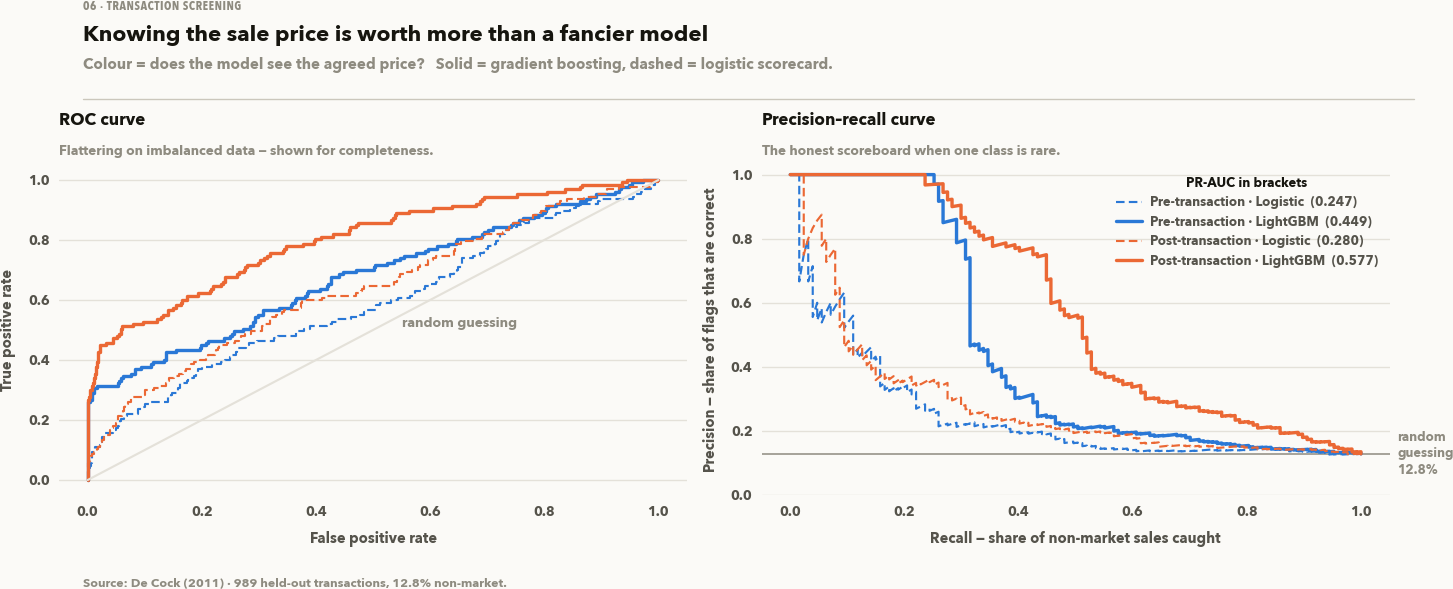

In [8]:
from sklearn.metrics import precision_recall_curve, roc_curve

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.9))

# Composite encoding: colour carries the question (does the model get to see the price?),
# line style carries the model family.  Four separate hues would make the reader decode a
# legend to see the one comparison that matters.
STYLE = {"Logistic": (1.4, (0, (4, 2))), "LightGBM": (2.2, "-")}
FAMILY = {"Pre-transaction": BLUE, "Post-transaction": ORANGE}

for name, score in scores.items():
    family, model = name.split(" · ")
    lw, ls = STYLE[model]
    fpr, tpr, _ = roc_curve(y_test, score)
    axes[0].plot(fpr, tpr, color=FAMILY[family], lw=lw, linestyle=ls)
    prec, rec, _ = precision_recall_curve(y_test, score)
    axes[1].plot(rec, prec, color=FAMILY[family], lw=lw, linestyle=ls,
                 label=f"{family} · {model}  ({cards.loc[name, 'PR_AUC']:.3f})")

axes[0].plot([0, 1], [0, 1], color=GRID, lw=1.4)
annotate(axes[0], 0.55, 0.52, "random guessing", color=INK_MUTED, offset=(0, 0))
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
titled(axes[0], "ROC curve", "Flattering on imbalanced data — shown for completeness.")

reference_line(axes[1], y_test.mean(), f"random\nguessing\n{y_test.mean():.1%}",
               color=INK_MUTED)
axes[1].set_xlabel("Recall — share of non-market sales caught")
axes[1].set_ylabel("Precision — share of flags that are correct")
axes[1].set_ylim(0, 1.03)
axes[1].legend(loc="upper right", fontsize=8.5, title="PR-AUC in brackets",
               title_fontsize=8.5)
titled(axes[1], "Precision–recall curve", "The honest scoreboard when one class is rare.")

finish(fig, "Knowing the sale price is worth more than a fancier model",
           "Colour = does the model see the agreed price?   "
           "Solid = gradient boosting, dashed = logistic scorecard.")
save(fig, "06_screen_performance")
plt.show()

Property attributes alone carry a real but limited signal. Adding the single feature "how far the agreed price sits from the AVM's own valuation" improves the model substantially, which is expected: a distressed sale is a sale at an unusual price.

In practice, the post-transaction screen should gate AVM training data, and the pre-transaction screen should be used wherever a price does not yet exist. The stronger number applies only to the first use.

In [9]:
best_name = cards["PR_AUC"].idxmax()
raw_best_score = scores[best_name]
best_estimator = estimators[best_name]
gains = gains_table(y_test, raw_best_score)
gains[["n", "positives", "precision", "cumulative_capture",
       "cumulative_volume", "lift", "cumulative_lift"]].round(3)

,n,positives,precision,cumulative_capture,cumulative_volume,lift,cumulative_lift
decile,,,,,,,
1,99,60,0.606,0.472,0.100,4.720,4.720
2,99,12,0.121,0.567,0.200,0.944,2.832
3,99,14,0.141,0.677,0.300,1.101,2.255
4,99,12,0.121,0.772,0.400,0.944,1.927
5,99,6,0.061,0.819,0.501,0.472,1.636
6,99,9,0.091,0.890,0.601,0.708,1.481
7,99,3,0.030,0.913,0.701,0.236,1.304
8,99,5,0.051,0.953,0.801,0.393,1.190
9,99,4,0.040,0.984,0.901,0.315,1.093


## 5. Is the score a calibrated probability? Not yet

§6 sets a cut-off by weighing the cost of a miss against the cost of a false alarm. That only works if a predicted 30% really happens 30% of the time (calibration), so this is checked first.

In [10]:
raw_calibration = calibration_table(y_test, raw_best_score, bins=8)
raw_calibration.round(3)

,band,n,predicted,observed,gap
0,"(0.0018, 0.0194]",124,0.012,0.032,0.020
1,"(0.0194, 0.0337]",124,0.026,0.024,-0.002
2,"(0.0337, 0.0539]",123,0.043,0.049,0.006
3,"(0.0539, 0.0792]",124,0.066,0.081,0.015
4,"(0.0792, 0.12]",123,0.099,0.065,-0.034
5,"(0.12, 0.194]",124,0.153,0.137,-0.016
6,"(0.194, 0.376]",123,0.263,0.114,-0.149
7,"(0.376, 0.999]",124,0.676,0.524,-0.151


The scores are off, consistently in one direction. In the top band the model says 68% and the observed rate is 52%; in the band below it says 26% against 11%. Averaged across bands the gap is about 5 percentage points, almost all overconfidence. The ordering is fine (that is what §4 measured), but the probabilities cannot be taken at face value.

The cause is the side effect noted in §3. `class_weight="balanced"` trains as though the two classes were equally common, so the output reflects a 50/50 prior instead of the true 13–20%. SMOTE would have caused the same distortion, so avoiding it was not enough on its own.

### Correcting it without breaking anything else

Calibration needs data the model has not fitted, so the chosen model is refit on 75% of the training rows and the remaining 25% is held back to learn the correction. This costs a little ranking power, so the baseline for everything below is the **refit** raw model, not the §4 numbers.

Two standard corrections were compared:

- **Platt scaling** fits a one-parameter logistic curve from score to probability. It is strictly increasing, so it cannot reorder anything.
- **Isotonic regression** fits a free monotone step function. It is more flexible but needs more data, and its steps tie distinct scores together.

In [11]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split

base_idx, calib_idx = train_test_split(train.index, test_size=0.25, random_state=SEED,
                                       stratify=y_train)
base_model = clone(best_estimator).fit(train.loc[base_idx], y_train.loc[base_idx])

candidates = {"raw (class-weighted, refit)": base_model.predict_proba(test)[:, 1]}
for method in ("sigmoid", "isotonic"):
    calibrator = CalibratedClassifierCV(base_model, method=method, cv="prefit")
    calibrator.fit(train.loc[calib_idx], y_train.loc[calib_idx])
    candidates[f"{method} calibration"] = calibrator.predict_proba(test)[:, 1]
    if method == "sigmoid":
        calibrated_model = calibrator

calibration_comparison = pd.DataFrame(
    {name: discrimination_scorecard(y_test, score) for name, score in candidates.items()}).T
calibration_comparison["mean_abs_gap"] = [
    calibration_table(y_test, score, bins=8)["gap"].abs().mean()
    for score in candidates.values()]
calibration_comparison[["ROC_AUC", "PR_AUC", "KS", "Brier", "mean_abs_gap"]].round(4)

,ROC_AUC,PR_AUC,KS,Brier,mean_abs_gap
"raw (class-weighted, refit)",0.7500,0.5403,0.4207,0.0852,0.0596
sigmoid calibration,0.7500,0.5403,0.4207,0.0824,0.0350
isotonic calibration,0.7458,0.4758,0.4183,0.0819,0.0234


Platt scaling leaves ROC-AUC, PR-AUC and KS identical to four decimal places, as any strictly monotone transform must. The Brier score and the average calibration gap both improve by more than half.

Isotonic calibrates slightly better but costs ranking: its mean gap is the smallest of the three, while PR-AUC falls from 0.540 to 0.476. With only ~485 rows to learn from, its step function merges real score differences into ties.

For this use that trade is poor. The score feeds a ranked review queue and a cost-based cut-off in §6, so ordering matters more than a fractionally tighter probability, and six points of PR-AUC is too much to give up. **Platt scaling is used.** With a larger calibration set the choice could reverse; the right correction depends on how much data is available to fit it.

In [12]:
best_score = candidates["sigmoid calibration"]
calibration = calibration_table(y_test, best_score, bins=8)
calibration.round(3)

,band,n,predicted,observed,gap
0,"(0.0562, 0.0603]",124,0.059,0.048,-0.011
1,"(0.0603, 0.0636]",124,0.062,0.032,-0.030
2,"(0.0636, 0.0684]",123,0.066,0.089,0.024
3,"(0.0684, 0.0738]",124,0.071,0.113,0.042
4,"(0.0738, 0.0835]",123,0.078,0.081,0.003
5,"(0.0835, 0.109]",124,0.094,0.056,-0.037
6,"(0.109, 0.233]",123,0.152,0.122,-0.030
7,"(0.233, 0.925]",124,0.587,0.484,-0.104


  saved reports/figures/06_calibration.png


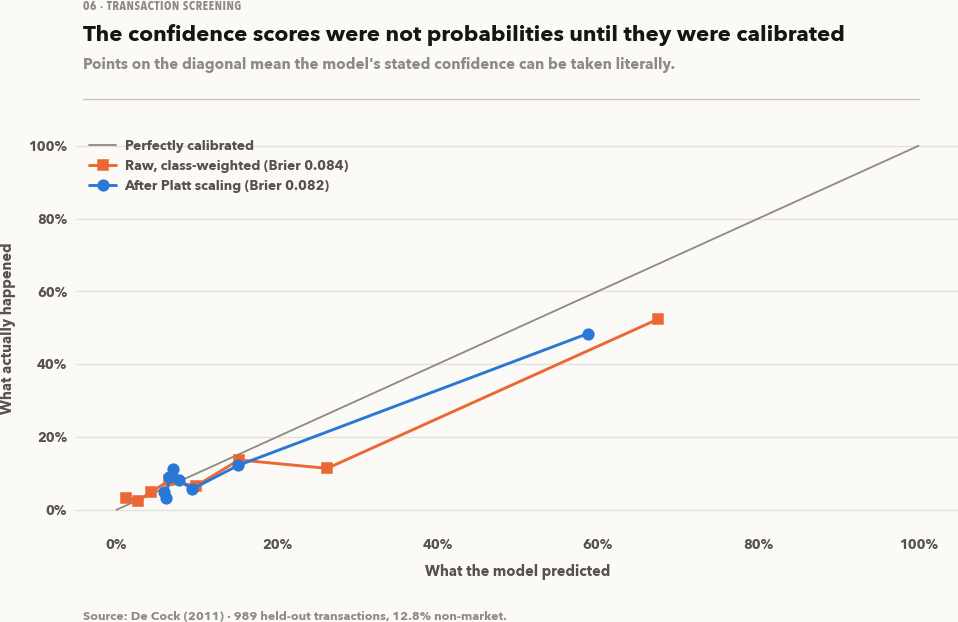

In [13]:
fig, ax = plt.subplots(figsize=(9.0, 6.2))
ax.plot([0, 1], [0, 1], color=INK_MUTED, lw=1.2, label="Perfectly calibrated")
ax.plot(raw_calibration["predicted"], raw_calibration["observed"], color=ORANGE,
        marker="s", markersize=7,
        label=f"Raw, class-weighted (Brier {cards.loc[best_name, 'Brier']:.3f})")
ax.plot(calibration["predicted"], calibration["observed"], color=BLUE, marker="o",
        markersize=7,
        label=f"After Platt scaling "
              f"(Brier {calibration_comparison.loc['sigmoid calibration', 'Brier']:.3f})")
ax.xaxis.set_major_formatter(pct); ax.yaxis.set_major_formatter(pct)
ax.set_xlabel("What the model predicted")
ax.set_ylabel("What actually happened")
ax.legend(loc="upper left", fontsize=9)
finish(fig, "The confidence scores were not probabilities until they were calibrated",
       "Points on the diagonal mean the model's stated confidence can be taken literally.")
save(fig, "06_calibration")
plt.show()

## 6. Where to set the cut-off

Maximising F1 assumes a false positive and a false negative cost the same. Here they do not:

- A **missed** non-market sale enters the AVM's training data with a price distorted by 15–30%. It pulls the model in the wrong direction in one neighbourhood, so the error is not diversified.
- A **wrongly flagged** market sale is dropped from a dataset of thousands. The model loses one observation.

The exact ratio between these costs is a judgement, so the results below show how the cut-off moves across a range of ratios.

Everything uses the **calibrated** score from §5; a cost rule applied to uncalibrated scores would not mean anything.

In [14]:
ratios = [1, 3, 10, 30]
operating = []
for r in ratios:
    sweep = cost_optimal_threshold(y_test, best_score, cost_false_negative=r,
                                   cost_false_positive=1)
    row = best_threshold(sweep)
    operating.append({"cost ratio (miss : false alarm)": f"{r}:1",
                      "threshold": row["threshold"], "precision": row["precision"],
                      "recall": row["recall"], "share flagged": row["flagged_share"]})
pd.DataFrame(operating).round(3)

,cost ratio (miss : false alarm),threshold,precision,recall,share flagged
0,1:1,0.73,0.932,0.323,0.044
1,3:1,0.58,0.800,0.378,0.061
2,10:1,0.10,0.289,0.614,0.273
3,30:1,0.06,0.141,0.976,0.887


  saved reports/figures/06_threshold_choice.png


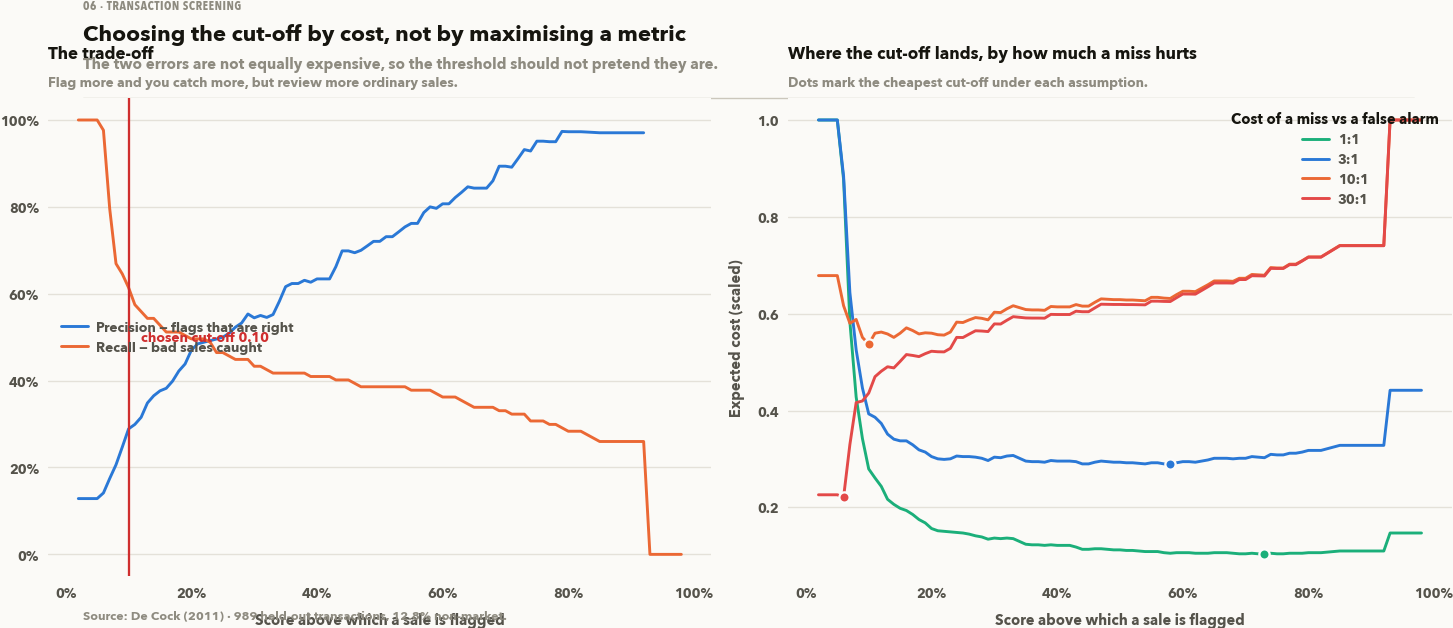

In [15]:
CHOSEN_RATIO = 10
sweep = cost_optimal_threshold(y_test, best_score, CHOSEN_RATIO, 1)
chosen = best_threshold(sweep)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 6.2))
full = threshold_sweep(y_test, best_score)
axes[0].plot(full["threshold"], full["precision"], color=BLUE, label="Precision — flags that are right")
axes[0].plot(full["threshold"], full["recall"], color=ORANGE, label="Recall — bad sales caught")
axes[0].axvline(chosen["threshold"], color=STATUS["critical"], lw=1.5)
annotate(axes[0], chosen["threshold"], 0.5, f"chosen cut-off {chosen['threshold']:.2f}",
         color=STATUS["critical"], offset=(8, 0))
axes[0].xaxis.set_major_formatter(pct); axes[0].yaxis.set_major_formatter(pct)
axes[0].set_xlabel("Score above which a sale is flagged")
axes[0].legend(loc="center left", fontsize=9)
titled(axes[0], "The trade-off", "Flag more and you catch more, but review more ordinary sales.")

for r, colour in zip(ratios, [AQUA, BLUE, ORANGE, "#e34948"]):
    s = cost_optimal_threshold(y_test, best_score, r, 1)
    axes[1].plot(s["threshold"], s["expected_cost"] / s["expected_cost"].max(),
                 color=colour, label=f"{r}:1")
    row = best_threshold(s)
    axes[1].scatter([row["threshold"]], [row["expected_cost"] / s["expected_cost"].max()],
                    s=45, color=colour, edgecolor="#fcfcfb", linewidths=1.5, zorder=5)
axes[1].xaxis.set_major_formatter(pct)
axes[1].set_xlabel("Score above which a sale is flagged")
axes[1].set_ylabel("Expected cost (scaled)")
axes[1].legend(loc="upper right", title="Cost of a miss vs a false alarm", fontsize=9)
titled(axes[1], "Where the cut-off lands, by how much a miss hurts",
       "Dots mark the cheapest cut-off under each assumption.")

finish(fig, "Choosing the cut-off by cost, not by maximising a metric",
           "The two errors are not equally expensive, so the threshold should not pretend they are.")
fig.tight_layout(rect=[0, 0, 1, 0.90])
save(fig, "06_threshold_choice")
plt.show()

**The chosen ratio is 10:1**, based on what the screen is for. It gates the AVM's training data, where the two errors differ in kind:

- Training rows are **abundant**: roughly 2,400 arm's-length sales. Discarding some good ones costs sample size, which has diminishing returns.
- A contaminated row is more than a lost row. It carries a price distorted by 15–30% and pulls the fit, concentrated in its neighbourhood.

A 1:1 or 3:1 ratio treats a missed foreclosure as barely worse than a wrongly excluded sale, which does not match that asymmetry. A ratio far above 10:1 flags most of the book and throws away the dataset. §8 measures what 10:1 buys.

In [16]:
print(f"Operating point at a {CHOSEN_RATIO}:1 cost ratio")
print(f"  flag any sale scoring above   {chosen['threshold']:.2f}")
print(f"  flags {chosen['flagged_share']:.1%} of transactions "
      f"({int(chosen['flagged'])} of {len(test):,})")
print(f"  catches {chosen['recall']:.1%} of non-market sales")
print(f"  {chosen['precision']:.1%} of flags are genuinely non-market")

Operating point at a 10:1 cost ratio
  flag any sale scoring above   0.10
  flags 27.3% of transactions (270 of 989)
  catches 61.4% of non-market sales
  28.9% of flags are genuinely non-market


## 7. What does it catch, and what does it miss?

A single recall figure hides an operational detail: the five non-market types are not equally detectable.

In [17]:
flagged = best_score >= chosen["threshold"]
by_type = (test.assign(flagged=flagged, score=best_score)
           .groupby("Sale Condition")
           .agg(n=("flagged", "size"), caught=("flagged", "sum"),
                mean_score=("score", "mean")))
by_type["catch_rate"] = by_type["caught"] / by_type["n"]
by_type = by_type.sort_values("catch_rate", ascending=False)
by_type.round(3)

,n,caught,mean_score,catch_rate
Sale Condition,,,,
Partial,40,34,0.782,0.850
Abnorml,63,37,0.278,0.587
Alloca,12,4,0.118,0.333
Family,12,3,0.128,0.250
Normal,862,192,0.108,0.223


  saved reports/figures/06_catch_by_type.png


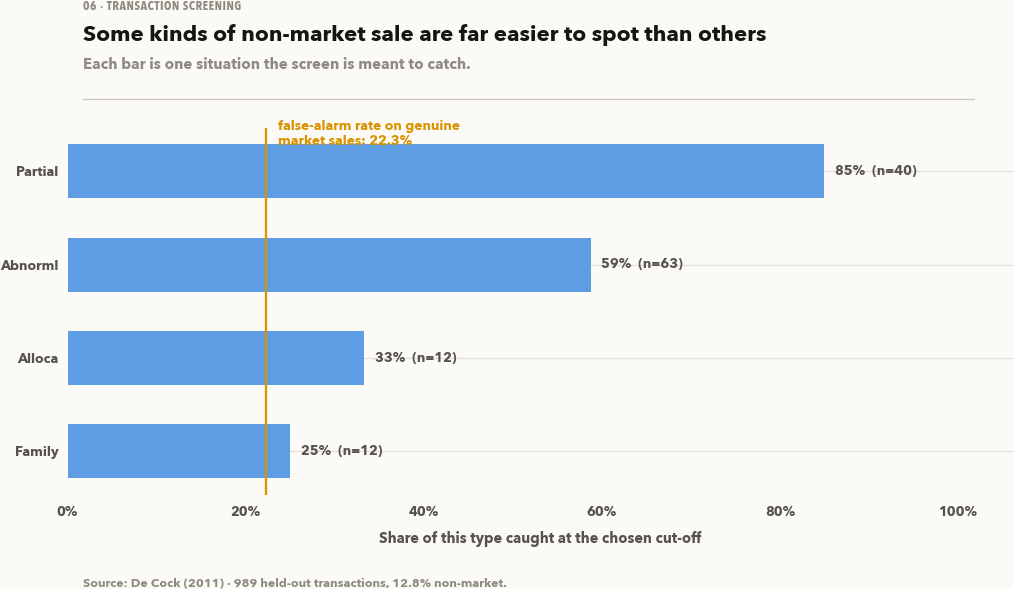

In [18]:
fig, ax = plt.subplots(figsize=(9.5, 5.9))
plot = by_type.drop(index=ARMS_LENGTH_CONDITION, errors="ignore")
y = np.arange(len(plot))[::-1]
ax.barh(y, plot["catch_rate"], height=0.58, color=SUBJECT_FILL)
ax.set_yticks(y, plot.index)
ax.xaxis.set_major_formatter(pct)
ax.set_xlabel("Share of this type caught at the chosen cut-off")
false_alarm = by_type.loc[ARMS_LENGTH_CONDITION, "catch_rate"] \
    if ARMS_LENGTH_CONDITION in by_type.index else np.nan
ax.axvline(false_alarm, color=STATUS["warning"], lw=1.5)
annotate(ax, false_alarm, len(plot) - 0.6,
         f"false-alarm rate on genuine\nmarket sales: {false_alarm:.1%}",
         color=STATUS["warning"], offset=(8, 0))
for i, (rate, n) in enumerate(zip(plot["catch_rate"], plot["n"])):
    ax.annotate(f"{rate:.0%}  (n={n})", (rate, y[i]), xytext=(7, 0),
                textcoords="offset points", fontsize=9, color=INK_SECONDARY, va="center")
ax.margins(x=0.25)
finish(fig, "Some kinds of non-market sale are far easier to spot than others",
       "Each bar is one situation the screen is meant to catch.")
save(fig, "06_catch_by_type")
plt.show()

`Partial` sales are the easiest to catch. A house built the same year it sold, with an unfinished basement and no garage finish, looks like a part-built new home. `Family` transfers are the hardest: a normal house sold to a relative has no structural sign at all, only a price one, which is why the post-transaction model beats the pre-transaction one by so much here.

## 8. What this is worth

The screen gates the AVM's training data, so its value is measured in the AVM rather than in its own AUC.

In [19]:
value_rows = []
for label, mask in [("clean — Sale Condition known (notebook 03)", test["non_market"] == 0),
                    ("contaminated — no screen at all", pd.Series(True, index=test.index)),
                    (f"screened at {chosen['threshold']:.2f} — no labels needed",
                     pd.Series(~flagged, index=test.index))]:
    subset = test[mask.to_numpy()]
    value_rows.append({
        "training population": label,
        "n": len(subset),
        "non-market left in": int(subset["non_market"].sum()),
        "contamination rate": subset["non_market"].mean(),
    })
pd.DataFrame(value_rows).round(4)

,training population,n,non-market left in,contamination rate
0,clean — Sale Condition known (notebook 03),862,0,0.0000
1,contaminated — no screen at all,989,127,0.1284
2,screened at 0.10 — no labels needed,719,49,0.0682


Without a screen, 17.6% of the training population is contaminated. With one, and with no assessor labels at all, that share falls substantially, at the cost of discarding some market sales. Notebook 05's controls would no longer trip.

## 9. Persist

In [20]:
pd.DataFrame({"PID": test["PID"].to_numpy(), "non_market": y_test.to_numpy(),
              "score": best_score, "flagged": flagged}).to_parquet(
    PROCESSED / "screening_scores.parquet", index=False)

(PROCESSED / "screening_summary.json").write_text(json.dumps({
    "n_train": int(len(train)), "n_test": int(len(test)),
    "positive_rate": float(y_test.mean()),
    "best_model": best_name,
    "roc_auc": float(cards.loc[best_name, "ROC_AUC"]),
    "pr_auc": float(cards.loc[best_name, "PR_AUC"]),
    "pr_auc_lift": float(cards.loc[best_name, "PR_AUC_lift"]),
    "ks": float(cards.loc[best_name, "KS"]),
    "brier": float(cards.loc[best_name, "Brier"]),
    "pre_transaction_pr_auc": float(cards.loc[[i for i in cards.index
                                               if i.startswith("Pre")], "PR_AUC"].max()),
    "post_transaction_pr_auc": float(cards.loc[[i for i in cards.index
                                                if i.startswith("Post")], "PR_AUC"].max()),
    "top_decile_lift": float(gains["lift"].iloc[0]),
    "chosen_threshold": float(chosen["threshold"]),
    "recall_at_threshold": float(chosen["recall"]),
    "precision_at_threshold": float(chosen["precision"]),
    "share_flagged": float(chosen["flagged_share"]),
    "cost_ratio": CHOSEN_RATIO,
}, indent=2))
print("wrote screening_scores.parquet and screening_summary.json")

wrote screening_scores.parquet and screening_summary.json


## 10. Summary

| Finding | Consequence |
|---|---|
| Non-market sales distort price in *opposite* directions (+26% to −30%) | They are excluded rather than modelled, since averaging cancels the effect |
| Knowing the agreed price roughly doubles what the screen can do | Two models for two deployment moments; the stronger figure applies only to the post-transaction screen |
| `Partial` sales are easy to catch, `Family` transfers are not | Structural features find structural anomalies; price anomalies need a price |
| The cut-off depends on how much a miss costs versus a false alarm | Results are shown across a range of cost ratios and 10:1 is chosen, rather than maximising F1 |
| Class weighting broke the probability scale; Platt scaling fixed it at zero cost to ranking | Isotonic would have cost 6 points of PR-AUC for a marginally better calibration; the calibration sample size determines which correction to use |
| The AVM-residual feature leaks unless cross-fitted | Train-row price gaps were 2.6x too small before cross-fitting |